In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
df = pd.read_csv('Iris.csv')

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df = df.iloc[:,1:]

In [5]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
encoder = LabelEncoder()

In [8]:
df['Species'] = encoder.fit_transform(df['Species'])

In [9]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
df['Species'].unique()

array([0, 1, 2])

## Binary classification banacchi
Here 1,2 besi overlap korse toh tai ei duita 

In [11]:
df=df[df['Species']!=0]

In [12]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [13]:
df['Species'].unique()

array([1, 2])

In [14]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [15]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

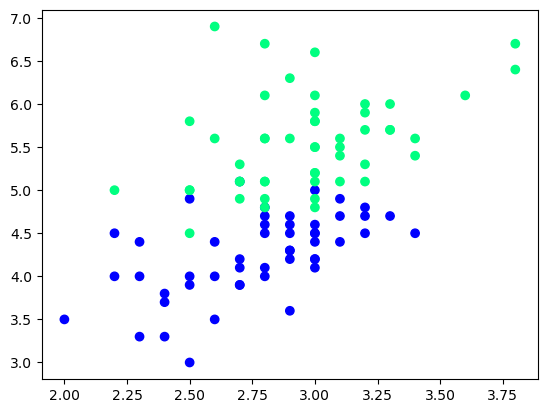

In [17]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [21]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
54,2.8,4.6,1
122,2.8,6.7,2
91,3.0,4.6,1
143,3.2,5.9,2
90,2.6,4.4,1
96,2.9,4.2,1
132,2.8,5.6,2
125,3.2,6.0,2
111,2.7,5.3,2
73,2.8,4.7,1


In [22]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [23]:
df_train

,SepalWidthCm,PetalLengthCm,Species
102,3.0,5.9,2
84,3.0,4.5,1
143,3.2,5.9,2
100,3.3,6.0,2
113,2.5,5.0,2
55,2.8,4.5,1
105,3.0,6.6,2
142,2.7,5.1,2
97,2.9,4.3,1
109,3.6,6.1,2


In [24]:
df_val

,SepalWidthCm,PetalLengthCm,Species
141,3.1,5.1,2
57,2.4,3.3,1
80,2.4,3.8,1
72,2.5,4.9,1
145,3.0,5.2,2


In [25]:
df_test

,SepalWidthCm,PetalLengthCm,Species
115,3.2,5.3,2
54,2.8,4.6,1
87,2.3,4.4,1
129,3.0,5.8,2
136,3.4,5.6,2


In [26]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [28]:
X_test

array([[3.1, 5.1],
       [2.4, 3.3],
       [2.4, 3.8],
       [2.5, 4.9],
       [3. , 5.2]])

In [27]:
y_test

array([2, 1, 1, 1, 2])

# Case 1 - Bagging

In [36]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
100,3.3,6.0,2
55,2.8,4.5,1
113,2.5,5.0,2
109,3.6,6.1,2
97,2.9,4.3,1
84,3.0,4.5,1
109,3.6,6.1,2
142,2.7,5.1,2


In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [38]:
dt_bag1 = DecisionTreeClassifier()

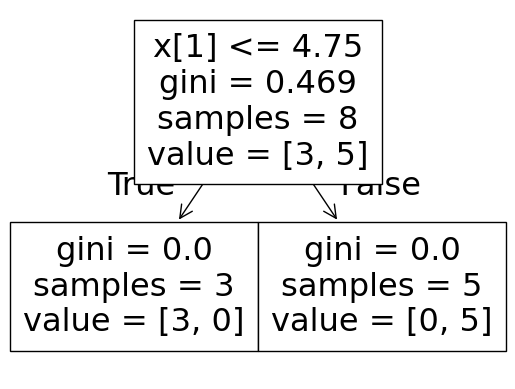

0.8


C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


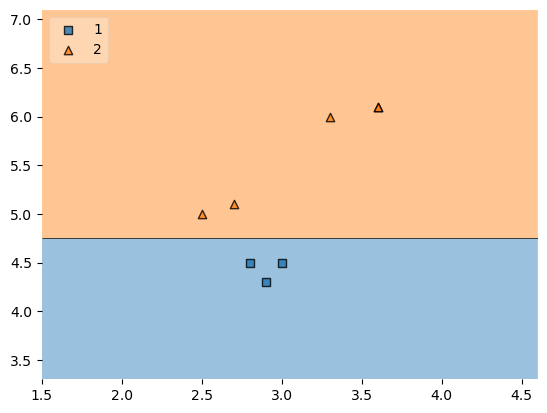

In [43]:
evaluate(dt_bag1,X,y)

In [53]:
# Data for Tree 2
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
55,2.8,4.5,1
102,3.0,5.9,2
143,3.2,5.9,2
100,3.3,6.0,2
113,2.5,5.0,2
109,3.6,6.1,2
102,3.0,5.9,2
143,3.2,5.9,2


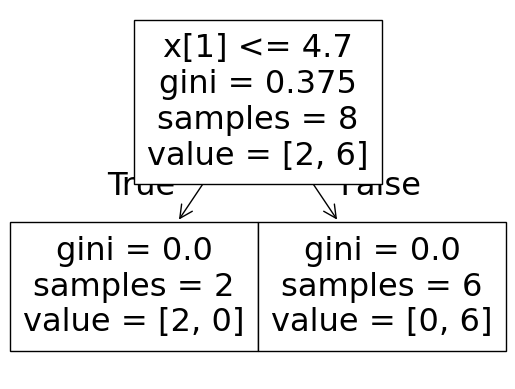

0.8


C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


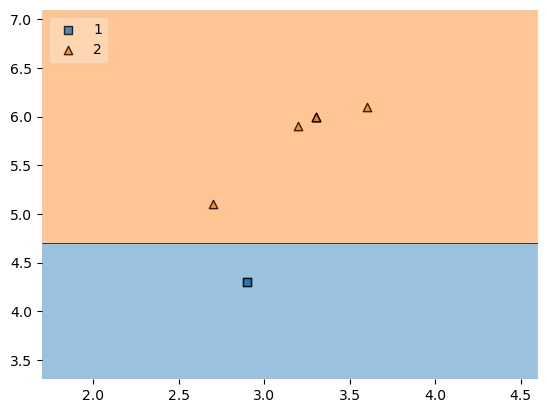

In [47]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [50]:
# Data for Tree 3
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
142,2.7,5.1,2
105,3.0,6.6,2
142,2.7,5.1,2
97,2.9,4.3,1
102,3.0,5.9,2
109,3.6,6.1,2
113,2.5,5.0,2
109,3.6,6.1,2


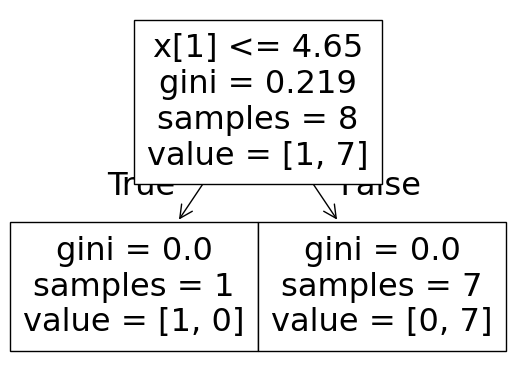

0.8


C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


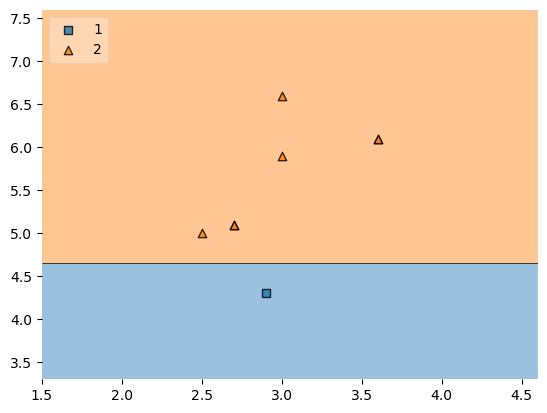

In [51]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [42]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

## Predict

In [57]:
df_test

,SepalWidthCm,PetalLengthCm,Species
115,3.2,5.3,2
54,2.8,4.6,1
87,2.3,4.4,1
129,3.0,5.8,2
136,3.4,5.6,2


## reshape() দেওয়া হয় কারণ scikit-learn-এর predict() input হিসেবে 2D array চায়।
[2.3, 4.4]->1D

[[2.3, 4.4]]->2D

In [61]:
print("Predictor 1",dt_bag1.predict(np.array([2.3,4.4]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.3,4.4]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.3,4.4]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [1]


C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [62]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
102,3.0,5.9,2
84,3.0,4.5,1
143,3.2,5.9,2
100,3.3,6.0,2
113,2.5,5.0,2
55,2.8,4.5,1
105,3.0,6.6,2
142,2.7,5.1,2
97,2.9,4.3,1
109,3.6,6.1,2


In [64]:
df_train.sample(8) #here replace=True nai

,SepalWidthCm,PetalLengthCm,Species
113,2.5,5.0,2
109,3.6,6.1,2
102,3.0,5.9,2
84,3.0,4.5,1
97,2.9,4.3,1
142,2.7,5.1,2
143,3.2,5.9,2
105,3.0,6.6,2


# Random Subspaces

In [65]:
df1 = pd.read_csv('Iris.csv')
df1 = df1.sample(10)

In [66]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
60,61,5.0,2.0,3.5,1.0,Iris-versicolor
140,141,6.7,3.1,5.6,2.4,Iris-virginica
112,113,6.8,3.0,5.5,2.1,Iris-virginica
102,103,7.1,3.0,5.9,2.1,Iris-virginica
14,15,5.8,4.0,1.2,0.2,Iris-setosa
131,132,7.9,3.8,6.4,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
30,31,4.8,3.1,1.6,0.2,Iris-setosa
116,117,6.5,3.0,5.5,1.8,Iris-virginica
55,56,5.7,2.8,4.5,1.3,Iris-versicolor


In [74]:
df1=df1.iloc[:,1:]

In [76]:
df1

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
140,6.7,3.1,5.6,2.4,Iris-virginica
112,6.8,3.0,5.5,2.1,Iris-virginica
102,7.1,3.0,5.9,2.1,Iris-virginica
14,5.8,4.0,1.2,0.2,Iris-setosa
131,7.9,3.8,6.4,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
30,4.8,3.1,1.6,0.2,Iris-setosa
116,6.5,3.0,5.5,1.8,Iris-virginica
55,5.7,2.8,4.5,1.3,Iris-versicolor


In [84]:
df1.sample(2,replace=True,axis=1)

,Species,Species
140,Iris-virginica,Iris-virginica
112,Iris-virginica,Iris-virginica
102,Iris-virginica,Iris-virginica
14,Iris-setosa,Iris-setosa
131,Iris-virginica,Iris-virginica
148,Iris-virginica,Iris-virginica
30,Iris-setosa,Iris-setosa
116,Iris-virginica,Iris-virginica
55,Iris-versicolor,Iris-versicolor


# Random Patches

In [85]:
df1

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
140,6.7,3.1,5.6,2.4,Iris-virginica
112,6.8,3.0,5.5,2.1,Iris-virginica
102,7.1,3.0,5.9,2.1,Iris-virginica
14,5.8,4.0,1.2,0.2,Iris-setosa
131,7.9,3.8,6.4,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
30,4.8,3.1,1.6,0.2,Iris-setosa
116,6.5,3.0,5.5,1.8,Iris-virginica
55,5.7,2.8,4.5,1.3,Iris-versicolor


In [87]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,SepalWidthCm,PetalWidthCm
30,3.1,0.2
140,3.1,2.4
30,3.1,0.2
30,3.1,0.2
116,3.0,1.8
112,3.0,2.1
30,3.1,0.2
102,3.0,2.1
